Supervised learning for fraud detection

     Amount   TimeGap  LocationCode  DeviceType  Frequency  MerchantCode  \
0  0.461194  0.851419     -1.876163   -1.596905  -0.676909     -0.067166   
1 -2.073682 -0.073755     -0.738387   -0.404505  -1.675023     -1.298910   
2 -0.494686 -1.408857     -0.441965    0.323446  -0.009482     -1.209635   
3 -0.175963 -1.498078      0.778826   -3.670504   1.196920      0.632353   
4 -1.492552  0.623636     -0.117572    0.627059   3.282870     -1.371141   

   Fraudulent  
0           0  
1           0  
2           0  
3           0  
4           0  
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       884
           1       0.90      0.61      0.73       116

    accuracy                           0.95      1000
   macro avg       0.92      0.80      0.85      1000
weighted avg       0.95      0.95      0.94      1000



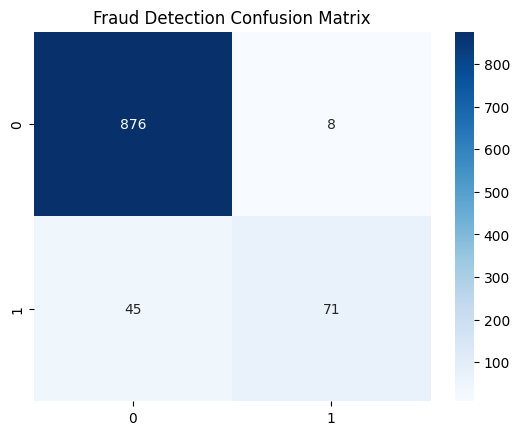

In [1]:
!pip install scikit-learn pandas matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Simulate a sample Fraud Data Set
# Create a sample fraud dataset
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=5000, n_features=6,
                           n_informative=4, n_redundant=0,
                           n_classes=2, weights=[0.9, 0.1],
                           random_state=42)

df_fraud = pd.DataFrame(X, columns=['Amount','TimeGap','LocationCode','DeviceType','Frequency','MerchantCode'])
df_fraud['Fraudulent'] = y

print(df_fraud.head())

# Split dataset
X = df_fraud.drop('Fraudulent', axis=1)
y = df_fraud['Fraudulent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Fraud Detection Confusion Matrix")
plt.show()


Unsupervised learning for segmentation.

Sample Customer Data:
   Age  Annual_Income  Spending_Score
0   56          72733              93
1   46          85318              46
2   32         129953               6
3   60         109474              99
4   25          43664              37


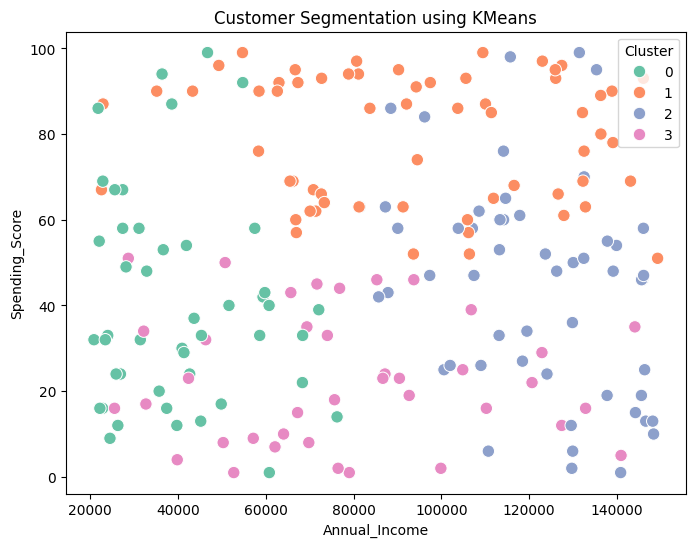


Cluster Interpretations:
   Cluster                                            Meaning
0        0         Budget Customers: Low income, low spending
1        1      Premium Customers: High income, high spending
2        2        Careful Spenders: High income, low spending
3        3  Young/Active Shoppers: Low-medium income, high...


In [ ]:
# -------------------------------
# Unsupervised Learning: Customer Segmentation
# -------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Simulate customer dataset
np.random.seed(42)
customer_data = pd.DataFrame({
    'Age': np.random.randint(18, 65, 200),
    'Annual_Income': np.random.randint(20000, 150000, 200),
    'Spending_Score': np.random.randint(1, 100, 200)
})

print("Sample Customer Data:")
print(customer_data.head())

# 2. Scale the features for clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_data)

# 3. Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_data['Cluster'] = kmeans.fit_predict(scaled_data)

# 4. Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual_Income', y='Spending_Score',
                hue='Cluster', data=customer_data,
                palette="Set2", s=80)
plt.title("Customer Segmentation using KMeans")
plt.show()

# 5. Create a clean table of cluster meanings
cluster_meanings = {
    0: "Budget Customers: Low income, low spending",
    1: "Premium Customers: High income, high spending",
    2: "Careful Spenders: High income, low spending",
    3: "Young/Active Shoppers: Low-medium income, high spending"
}

cluster_report = pd.DataFrame(list(cluster_meanings.items()),
                              columns=["Cluster", "Meaning"])
print("\nCluster Interpretations:")
print(cluster_report)

Sales Prediction with Linear Regression

   Advertising_Spend   Sales
0               4174  6838.2
1               4507  7432.6
2               1860  4117.0
3               2294  3046.2
4               2130  2955.0
Intercept: 2592.3477069110827
Coefficient: [0.95394906]
Mean Squared Error: 1476032.885910144
R² Score: 0.40472594830793285


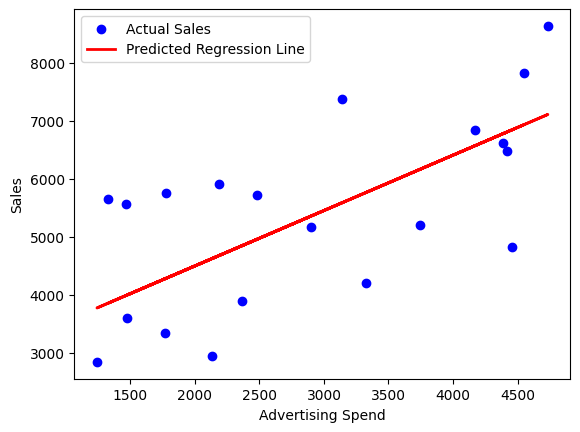

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. Simulate dataset (replace this with your own data)
# -----------------------------
np.random.seed(42)

# Suppose "Advertising Spend" is the feature (independent variable)
advertising_spend = np.random.randint(1000, 5000, 100)

# Sales is somewhat linearly dependent on ad spend + some noise
sales = 50 + 0.8 * advertising_spend + np.random.randint(1000, 5000, 100)

# Create dataframe
data = pd.DataFrame({
    "Advertising_Spend": advertising_spend,
    "Sales": sales
})

print(data.head())

# -----------------------------
# 2. Train-test split
# -----------------------------
X = data[["Advertising_Spend"]]   # Feature
y = data["Sales"]                 # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Train Linear Regression model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# 4. Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 5. Model evaluation
# -----------------------------
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# -----------------------------
# 6. Visualization
# -----------------------------
plt.scatter(X_test, y_test, color="blue", label="Actual Sales")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted Regression Line")
plt.xlabel("Advertising Spend")
plt.ylabel("Sales")
plt.legend()
plt.show()
